## Домашнее задание №4

Данное задание посвящено семантической сегментации. Ваша цель реализовать модель сегментации cпутниковых снимков на датасете [FloodNet Challenge](http://www.classic.grss-ieee.org/earthvision2021/challenge.html).. В первой части задания вы реализуете основные инструменты, которые необходимы для задачи сегментации: подсчет метрик, архитектуры, логгирование метрик. Во второй части вам предложено улучшить текущее решение и выбить заданные скор на задаче, используя любые трюки/идеи, которые вы сможете реализовать

## Часть 1: Базовое решение (1/3 от максимального числа баллов)
- Подсчет метрик
- Архитектуру модели (реализовать UNet)
- Обучение модели

### Loading dataset

In [289]:
# !gdown --id 1vLTGoRO1zeQSZ0mfRTgVC9W6R5Z94UoO

Распаковываем архив

In [290]:
# !tar -xzf tiny-floodnet-challenge.tar.gz

In [291]:
import os
os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"
os.environ["NUMEXPR_NUM_THREADS"] = "20"
os.environ["OPENBLAS_NUM_THREADS"] = "20"

import numpy as np

import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import ToTensor, PILToTensor, Compose

from IPython.display import clear_output


from tqdm.auto import tqdm
import time

In [292]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### Dataset

Датасет уже содержит разбиение на обучающую и тестовые выборки

In [293]:
import glob
import os
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

from PIL import Image

Для обработки изображений будем использовать библиотеку [albumentations](https://albumentations.ai/docs/). В ней содержиться больше аугментаций чем в torchvision, а также реализовано более удобная работа с аугментациями.

In [294]:
# !pip install albumentations -q

Реализуйте загрузку данных

In [295]:
class FloodNet(Dataset):
    """
    Классы:
    0: Background, 1: Building, 2: Road, 3: Water, 4: Tree, 5: Vehicle, 6: Pool, 7: Grass
    """

    def __init__(
        self,
        data_path: str,
        phase: str,
        augment: bool,
        img_size: int,
    ):
        self.num_classes = 8
        self.data_path = data_path
        self.phase = phase
        self.augment = augment
        self.img_size = img_size

        self.items = [
            filename.split(".")[0]
            for filename in os.listdir(f"{data_path}/{phase}/image")
        ]

        if augment:
            # TODO: Add your augmentations from albumentations
            # You can use self.transform = A.Compose([...])
            self.transform = A.Compose(
                [
                    A.PadIfNeeded(
                        min_height=img_size, min_width=img_size
                    ),  # чтобы не падать на маленьких изображениях
                    A.RandomCrop(width=img_size, height=img_size),
                    A.HorizontalFlip(p=0.5),
                    A.VerticalFlip(p=0.5),
                    A.RandomBrightnessContrast(p=0.2),
                    A.GaussianBlur(p=0.1),
                    A.HueSaturationValue(p=0.2),
                    A.Normalize(
                        mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
                    ),  # легко гуглится нужная нормализация
                    ToTensorV2(),
                ]
            )

        else:
            self.transform = A.Compose(
                [
                    A.PadIfNeeded(
                        min_height=img_size, min_width=img_size
                    ),  # чтобы не падать на маленьких изображениях
                    A.RandomCrop(width=img_size, height=img_size),
                    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                    ToTensorV2(),
                ]
            )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        image_path = f"{self.data_path}/{self.phase}/image/{self.items[index]}.jpg"
        mask_path = f"{self.data_path}/{self.phase}/mask/{self.items[index]}.png"

        image = np.array(Image.open(image_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        augmented = self.transform(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"]

        mask = mask.long()

        return image, mask

In [296]:
NUM_CLASSES = 8

In [297]:
train_dataset = FloodNet("tiny-floodnet-challenge", "train", True, 256)
test_dataset = FloodNet("tiny-floodnet-challenge", "test", False, 256)

Берем небольшой батч, так как иначе изображения не поместятся в память

In [298]:
train_dataloader = DataLoader(train_dataset, num_workers=0, batch_size=4, shuffle=True)

val_dataloader = DataLoader(test_dataset, num_workers=0, batch_size=1, shuffle=False)

### Metrics

Мы закончили с реализацией датасета. Теперь необходимо реализовать подсчет mIoU, mRecall, Overall Accuracy

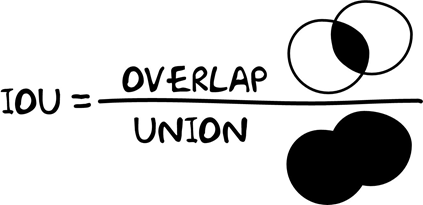

$mean IoU = \frac{1}{|classes|} \sum_{i=1}^{|classes|} IoU_i$

$mean Recall = \frac{1}{|classes|} \sum_{i=1}^{|classes|} \frac{intersection_i}{target_i}$

$Overall Acc = \frac{\sum_{i=1}^{|classes|} intersection_i}{\sum_{i=1}^{|classes|} target_i}$

In [299]:
def calc_val_data(preds, masks, num_classes):
    # preds: [batch_size, num_classes, H, W]
    # masks: [batch_size, H, W]
    preds = torch.argmax(preds, dim=1)  # [batch_size, H, W]
    batch_size = preds.shape[0]

    device = preds.device
    intersection = torch.zeros(
        batch_size, num_classes, device=device
    )  # TODO: calc intersection for each class [batch_size, num_classes]
    union = torch.zeros(
        batch_size, num_classes, device=device
    )  # TODO: calc union for each class [batch_size, num_classes]
    target = torch.zeros(
        batch_size, num_classes, device=device
    )  # TODO: calc number of pixels in ground truth mask per class [batch_size, num_classes]

    for i in range(num_classes):  # Go over all classes
        intersection_i = ((preds == i) & (masks == i)).sum(dim=(1, 2))
        union_i = ((preds == i) | (masks == i)).sum(dim=(1, 2))
        target_i = (masks == i).sum(dim=(1, 2))

        intersection[:, i] += intersection_i
        union[:, i] += union_i
        target[:, i] += target_i

    assert isinstance(intersection, torch.Tensor), "Output should be a tensor"
    assert isinstance(union, torch.Tensor), "Output should be a tensor"
    assert isinstance(target, torch.Tensor), "Output should be a tensor"

    assert intersection.shape == union.shape == target.shape, "Wrong output shape"
    assert (
        union.shape[0] == masks.shape[0] and union.shape[1] == num_classes
    ), "Wrong output shape"

    return intersection, union, target

In [300]:
def calc_val_loss(intersection, union, target, eps=1e-7):
    # During validation, intersection, union, and target are aggregated over the entire epoch.
    # Compute three metrics:
    # - mean IoU: macro-averaged over classes
    # - mean class recall: macro-averaged over classes
    # - overall pixel accuracy: global (not averaged over classes)

    if len(intersection.shape) == 1:
        intersection = intersection.unsqueeze(0)
        union = union.unsqueeze(0)
        target = target.unsqueeze(0)

    mean_iou = torch.mean(
        intersection / (union + eps), dim=1
    )  # TODO: calc mean class iou
    mean_class_rec = torch.mean(
        intersection / (target + eps), dim=1
    )  # TODO: calc mean class recall
    o_acc = torch.sum(intersection, dim=1) / (
        torch.sum(target, dim=1) + eps
    )  # TODO: calc overall accuracy

    return mean_iou, mean_class_rec, o_acc

In [301]:
# Let's check the correctness of the implementation

intersection = torch.tensor([8.0, 2.0])
union = torch.tensor([10.0, 5.0])
target = torch.tensor([9.0, 3.0])

mean_iou, mean_class_rec, o_acc = calc_val_loss(intersection, union, target, eps=1e-7)

assert abs(mean_iou.item() - 3 / 5) < 1e-6
assert abs(mean_class_rec.item() - 7 / 9) < 1e-6
assert abs(o_acc.item() - 5 / 6) < 1e-6

### Model

В качестве базовой модели будем использовать UNet. Архитектура представлена ниже. Вам не нужно точно воспроизвести архитектуру. Важно реализовать передачу intermediate features, полученные от encoder к decoder.

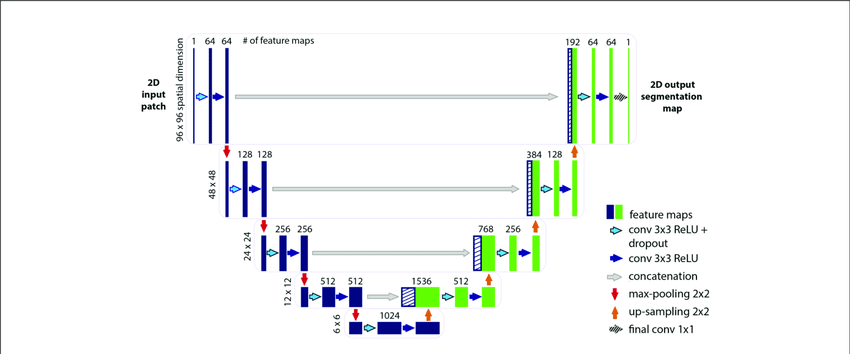

In [302]:
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import models


class DownBlock(nn.Module):
    def __init__(self, in_channel, out_channel, down=True):
        super().__init__()
        if down:
            self.down = nn.Conv2d(
                in_channel, in_channel, kernel_size=3, stride=2, padding=1
            )
        else:
            self.down = nn.Identity()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        x = self.down(x)
        x = self.conv(x)
        return x

In [303]:
class UpBlock(nn.Module):
    def __init__(self, in_channel, prev_channel, out_channel, up=True):
        super().__init__()

        if up:
            self.up = nn.ConvTranspose2d(
                in_channel, in_channel // 2, kernel_size=2, stride=2
            )
        else:
            self.up = nn.Identity()

        conv_in_ch = (
            (in_channel // 2 + prev_channel) if up else (in_channel + prev_channel)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(conv_in_ch, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x, res=None):
        x = self.up(x)
        if res is not None:
            x = torch.cat([x, res], dim=1)
        x = self.conv(x)
        return x

Теперь совместим encoder и decoder в одну архитектуру

In [304]:
class UNet(nn.Module):
    """
    Используя UpBlock и DownBlock, реализуйте полноценную архитектуру.
    Учтите, что разрешение изображений может не делиться на 2**num_down_blocks, поэтому
    вам нужно интерполировать его до нужного разрешения

    Для уменьшения/увеличения размерности можете использовать любой удобный вам метод
    """

    def __init__(
        self, num_classes, min_channels=32, max_channels=512, num_down_blocks=4
    ):
        super(UNet, self).__init__()

        self.num_classes = num_classes
        self.num_down_blocks = num_down_blocks

        self.down_blocks = nn.ModuleList()
        down_channels = []

        self.down_blocks.append(DownBlock(3, min_channels, down=False))
        down_channels.append(min_channels)

        cur_channels = min_channels
        for i in range(1, num_down_blocks):
            out_ch = min(max_channels, cur_channels * 2)
            self.down_blocks.append(DownBlock(cur_channels, out_ch, down=True))
            down_channels.append(out_ch)
            cur_channels = out_ch

        self.up_blocks = nn.ModuleList()
        skip_channels = down_channels[:-1][::-1]

        bottleneck_ch = down_channels[-1]

        for i in range(num_down_blocks - 1):
            skip_ch = skip_channels[i]
            out_ch = skip_ch
            self.up_blocks.append(UpBlock(bottleneck_ch, skip_ch, out_ch, up=True))
            bottleneck_ch = out_ch

        self.final_conv = nn.Conv2d(bottleneck_ch, num_classes, kernel_size=1)

    def forward(self, inputs):
        inputs = inputs.float()

        batch_size, _, h, w = inputs.shape

        factor = 2 ** (self.num_down_blocks - 1)
        new_h = int(np.ceil(h / factor) * factor)
        new_w = int(np.ceil(w / factor) * factor)
        if new_h != h or new_w != w:
            inputs = F.interpolate(
                inputs, size=(new_h, new_w), mode="bilinear", align_corners=True
            )

        residuals = []
        x = inputs
        for down_block in self.down_blocks:
            x = down_block(x)
            residuals.append(x)

        x = residuals.pop()
        for i, up_block in enumerate(self.up_blocks):
            skip = residuals.pop()
            x = up_block(x, skip)

        logits = self.final_conv(x)

        if new_h != h or new_w != w:
            logits = F.interpolate(
                logits, size=(h, w), mode="bilinear", align_corners=True
            )

        assert logits.shape == (
            batch_size,
            self.num_classes,
            h,
            w,
        ), f"Wrong shape: {logits.shape}, expected ({batch_size}, {self.num_classes}, {h}, {w})"
        return logits

### Training

Поменяю немного функцию цикла, так как tensorboard мне использовать не хочется.

In [305]:
def update_plots(history):
    plt.style.use("seaborn-v0_8-darkgrid")
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.tight_layout(pad=4.0)
    plt.ion()
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    epochs = range(1, len(history["train_loss"]) + 1)

    # 1. Лоссы (трейн и валидация)
    axs[0, 0].clear()
    axs[0, 0].plot(
        epochs,
        history["train_loss"],
        "o-",
        color=colors[0],
        linewidth=2,
        markersize=6,
        label="Train Loss",
    )
    axs[0, 0].plot(
        epochs,
        history["val_loss"],
        "s-",
        color=colors[1],
        linewidth=2,
        markersize=6,
        label="Val Loss",
    )
    axs[0, 0].set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    axs[0, 0].set_xlabel("Epochs", fontsize=12)
    axs[0, 0].set_ylabel("Loss", fontsize=12)
    axs[0, 0].legend(loc="best", frameon=True)
    axs[0, 0].grid(True, linestyle="--", alpha=0.7)

    # 2. Mean IoU
    axs[0, 1].clear()
    axs[0, 1].plot(
        epochs,
        history["val_mean_iou"],
        "D-",
        color=colors[2],
        linewidth=2.5,
        markersize=7,
    )
    axs[0, 1].set_title("Validation Mean IoU", fontsize=14, fontweight="bold")
    axs[0, 1].set_xlabel("Epochs", fontsize=12)
    axs[0, 1].set_ylabel("Mean IoU", fontsize=12)
    axs[0, 1].set_ylim(0, 1.0)
    axs[0, 1].grid(True, linestyle="--", alpha=0.7)

    # 3. Mean Class Recall
    axs[1, 0].clear()
    axs[1, 0].plot(
        epochs,
        history["val_mean_class_rec"],
        "^-",
        color=colors[3],
        linewidth=2.5,
        markersize=7,
    )
    axs[1, 0].set_title("Validation Mean Class Recall", fontsize=14, fontweight="bold")
    axs[1, 0].set_xlabel("Epochs", fontsize=12)
    axs[1, 0].set_ylabel("Recall", fontsize=12)
    axs[1, 0].set_ylim(0, 1.0)
    axs[1, 0].grid(True, linestyle="--", alpha=0.7)

    # 4. Overall Accuracy
    axs[1, 1].clear()
    axs[1, 1].plot(
        epochs,
        history["val_overall_acc"],
        "p-",
        color="#9467bd",
        linewidth=2.5,
        markersize=7,
    )
    axs[1, 1].set_title("Validation Overall Accuracy", fontsize=14, fontweight="bold")
    axs[1, 1].set_xlabel("Epochs", fontsize=12)
    axs[1, 1].set_ylabel("Accuracy", fontsize=12)
    axs[1, 1].set_ylim(0, 1.0)
    axs[1, 1].grid(True, linestyle="--", alpha=0.7)

    fig.tight_layout(pad=3.0)
    plt.draw()
    plt.pause(0.001)

    clear_output(wait=True)
    display(fig)

In [306]:
def train_segmentation_model(
    model,
    criterion,
    optimizer,
    train_dataloader,
    val_dataloader,
    num_epochs,
    device,
    calc_val_data=calc_val_data,
    calc_val_loss=calc_val_loss,
    update_plots=update_plots,
    num_classes=8,
    scheduler=None,
    plot_splits=5,
    save_path="best_model_final_iou_{iou:.4f}.pth",
):

    model.to(device)
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_mean_iou": [],
        "val_mean_class_rec": [],
        "val_overall_acc": [],
        "lr": [],
    }

    best_iou = 0.0
    best_state_dict = None
    global_step = 0
    plot_period = max(1, num_epochs // plot_splits)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        model.train()
        running_loss = 0.0

        # ---------- ОБУЧЕНИЕ ----------
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            if isinstance(pred, dict):
                pred = pred["out"]

            loss = criterion(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            global_step += 1

        # ---------- ОБНОВЛЕНИЕ ШЕДУЛЕРА (если задан) ----------
        if scheduler is not None:
            scheduler.step()

        # Сохраняем learning rate для графиков
        current_lr = optimizer.param_groups[0]["lr"]
        history["lr"].append(current_lr)

        avg_train_loss = running_loss / len(train_dataloader)
        history["train_loss"].append(avg_train_loss)

        # ---------- ВАЛИДАЦИЯ ----------
        model.eval()
        val_losses = []
        intersection = torch.zeros(num_classes, device=device)
        union = torch.zeros(num_classes, device=device)
        target_stats = torch.zeros(num_classes, device=device)

        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                if isinstance(pred, dict):
                    pred = pred["out"]

                loss = criterion(pred, y)
                val_losses.append(loss.item())

                tmp_i, tmp_u, tmp_t = calc_val_data(pred, y, num_classes)
                intersection += tmp_i.sum(dim=0)
                union += tmp_u.sum(dim=0)
                target_stats += tmp_t.sum(dim=0)

        mean_iou, mean_class_rec, overall_acc = calc_val_loss(
            intersection, union, target_stats
        )
        avg_val_loss = np.mean(val_losses)

        history["val_loss"].append(avg_val_loss)
        history["val_mean_iou"].append(mean_iou.item())
        history["val_mean_class_rec"].append(mean_class_rec.item())
        history["val_overall_acc"].append(overall_acc.item())

        # ---------- Сохраняем лучший чекпоинт только в память ----------
        if mean_iou.item() > best_iou:
            best_iou = mean_iou.item()
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # ---------- Визуализация ----------
        if update_plots is not None and (epoch % plot_period == 0 or epoch == num_epochs):
            update_plots(history)

        # ---------- Лог ----------
        t1 = time.time() - t0
        print(
            f"Epoch [{epoch}/{num_epochs}] "
            f"- LR: {current_lr:.6f} "
            f"- TrainLoss: {avg_train_loss:.4f} "
            f"- ValLoss: {avg_val_loss:.4f} "
            f"- mIoU: {mean_iou.item():.4f} "
            f"- Time: {t1:.1f}s"
        )

    # ---------- Сохранение лучшей модели ----------
    if best_state_dict is not None:
        torch.save(best_state_dict, save_path.format(iou=best_iou))
        print(
            f"\nЛучшая модель сохранена: {save_path.format(iou=best_iou)} "
            f"(mIoU = {best_iou:.4f})"
        )
    else:
        print("\nПредупреждение: не удалось сохранить лучший чекпоинт.")

    return history, best_iou


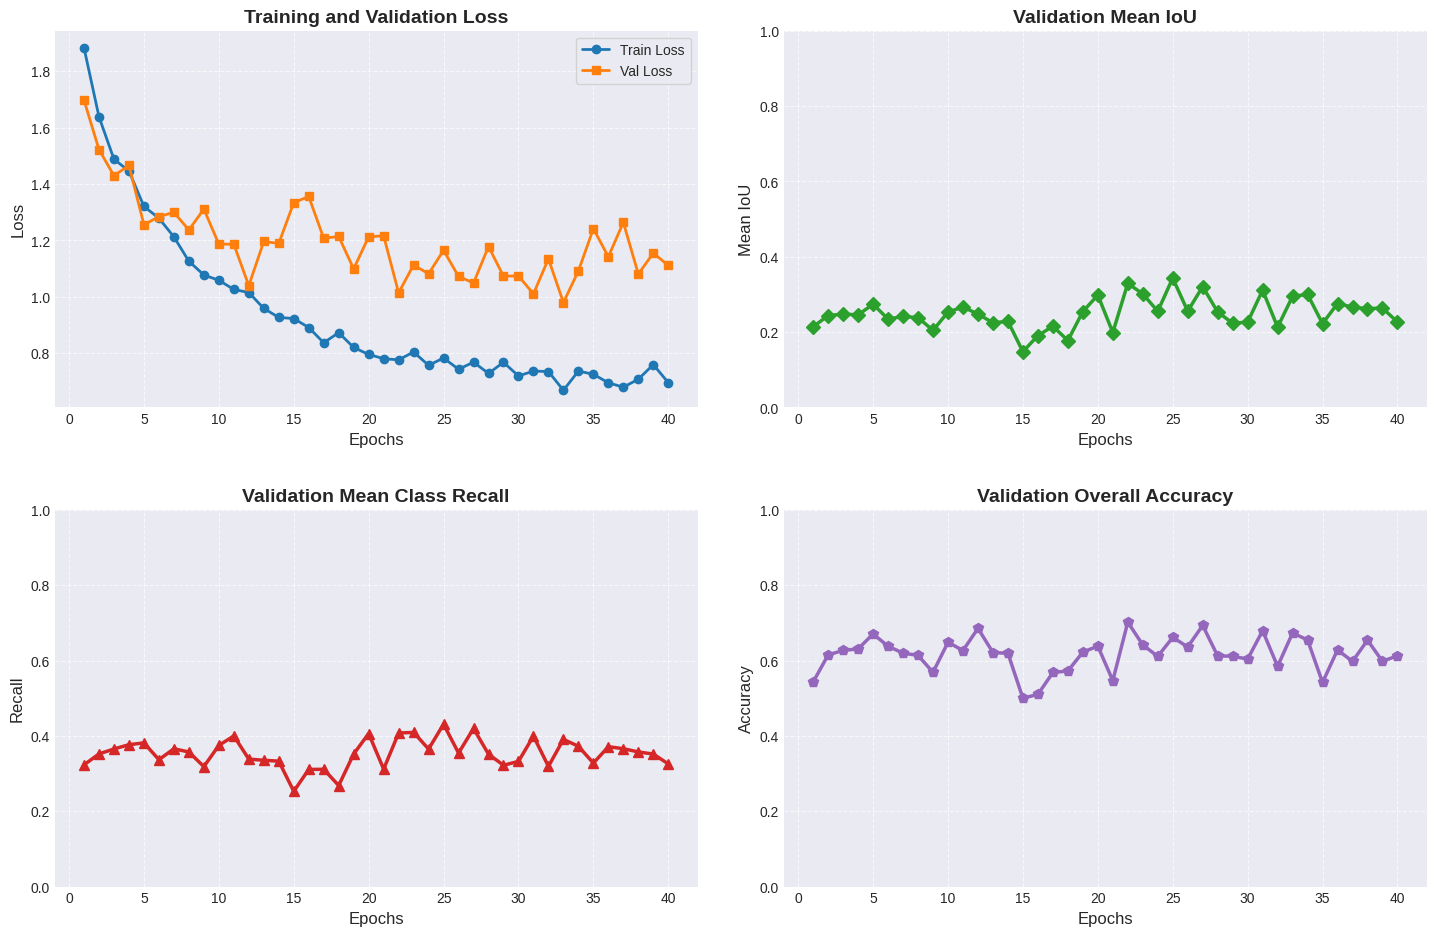

Epoch [40/40] - LR: 0.000100 - TrainLoss: 0.6960 - ValLoss: 1.1113 - mIoU: 0.2267 - Time: 6.2s

Лучшая модель сохранена: best_model_final_iou_0.3433.pth (mIoU = 0.3433)


In [307]:
m = UNet(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 40
plot_period = 5
history, best_iou = train_segmentation_model(
    model=m,
    criterion=criterion,
    optimizer=optim,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    num_epochs=num_epochs,
    device=device,
    calc_val_data=calc_val_data,
    calc_val_loss=calc_val_loss,
    update_plots=update_plots,
    num_classes=NUM_CLASSES,
)

In [308]:
# %load_ext tensorboard
# %tensorboard --logdir runs/

#### Визуализация работы модели на тестовой выборке

In [309]:
num_plots = 5

/home/udeneev-av/tmp/ipykernel_4076705/3314046167.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


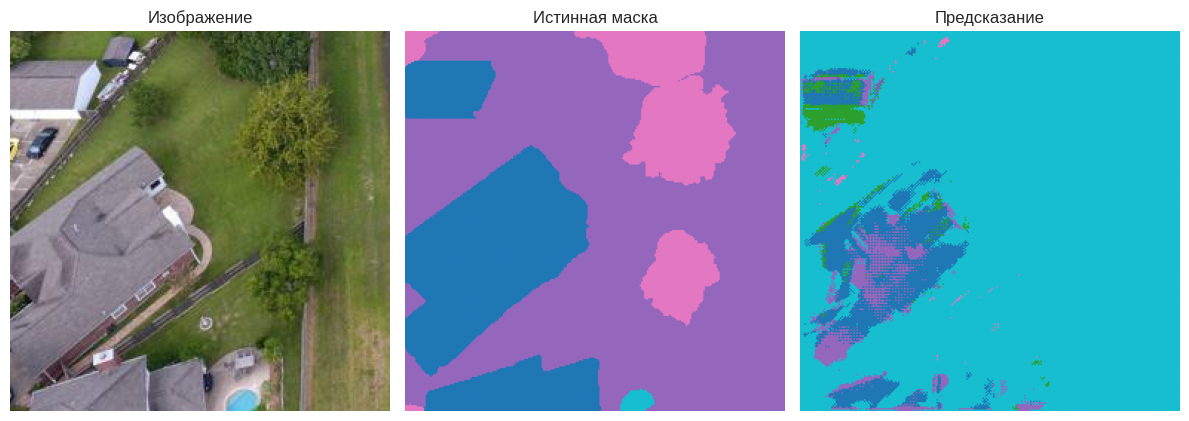

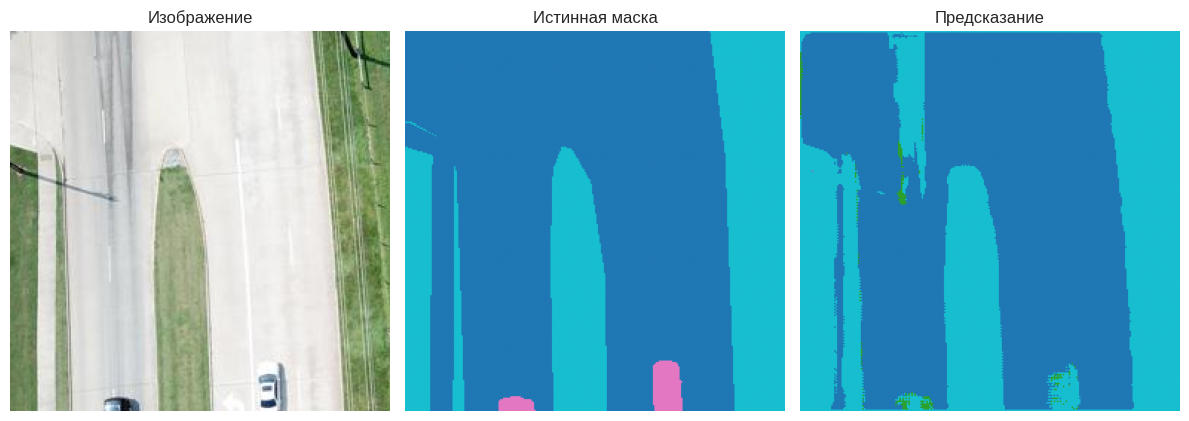

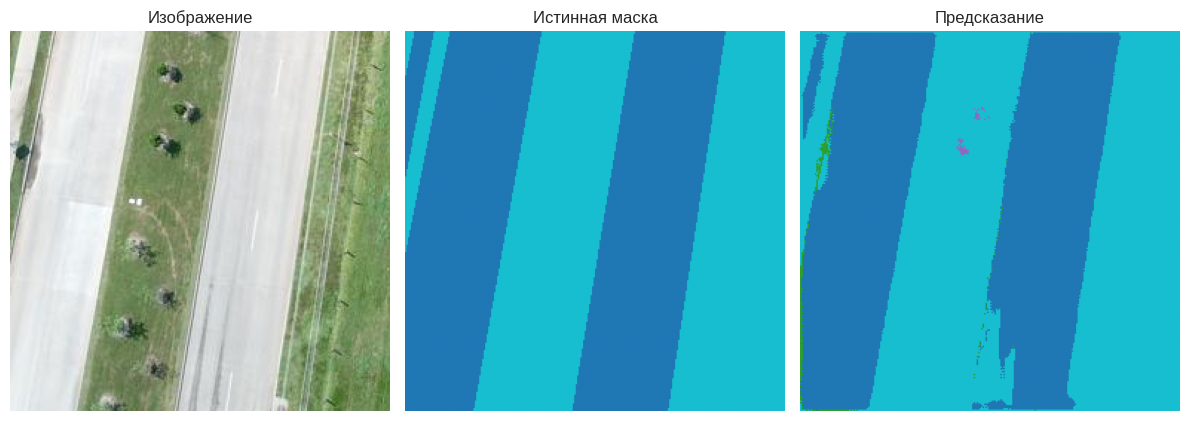

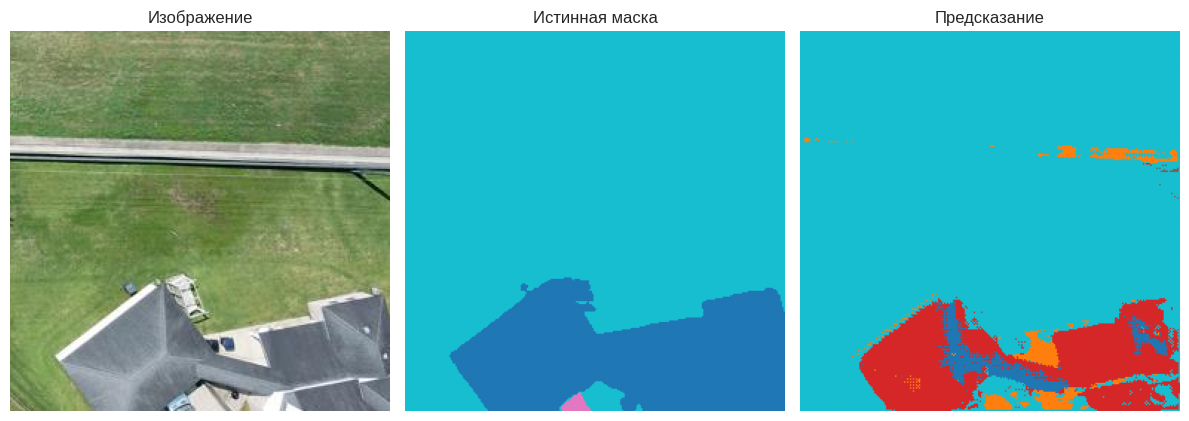

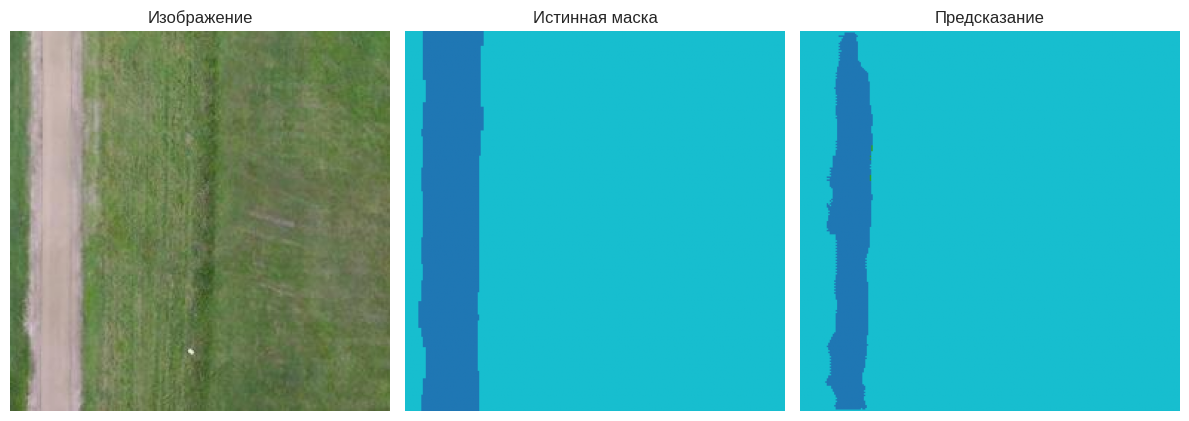

In [310]:
def denormalize(image, mean, std):
    image = image.float().clone()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    return image


def plot_results(model, image_number):
    image, mask = test_dataset[image_number]
    image = image.to(device)

    with torch.no_grad():
        pred = model(image.unsqueeze(0))
        if isinstance(pred, dict):
            pred = pred["out"]
        pred = torch.argmax(pred, dim=1).cpu().numpy()

    mask = mask.numpy()
    image = image.cpu()

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image = denormalize(image, mean, std)
    image = np.clip(image.numpy().transpose(1, 2, 0), 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    cmap = plt.cm.get_cmap("tab10")

    ax[0].imshow(image)
    ax[0].set_title("Изображение", fontsize=12)
    ax[0].axis("off")

    ax[1].imshow(mask, cmap=cmap, vmin=np.min(mask), vmax=np.max(mask))
    ax[1].set_title("Истинная маска", fontsize=12)
    ax[1].axis("off")

    ax[2].imshow(pred[0], cmap=cmap, vmin=np.min(mask), vmax=np.max(mask))
    ax[2].set_title("Предсказание", fontsize=12)
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


for i in range(num_plots):
    plot_results(m, i)

## Часть 2: Ваше решение (2/3 от максимального числа баллов)

В данной задаче предстоит выбить скор 45 mIoU на валидации.

Для решения можно использовать любые фреймворки, методы, модели.

Рекомендация к решению:
- Удобно будет воспользоваться предобученными моделями из [mmsegmentation](https://mmsegmentation.readthedocs.io/) или [torchvision](https://docs.pytorch.org/vision/main/models.html#semantic-segmentation)
- Для реализации аугментаций вы можете воспользоваться библиотекой [albumentations](https://albumentations.ai/docs/)


В качестве решения вам нужно предоставить:

- checkpoint вашей модели.
- скрипт с загрузкой модели и её инференса вашей модели на валидационной выборке.
- отчет о решении в TeX / Markdown.

Отчет должен включать себя:

- описание финального решения. Какие техники/методы/архитектуры вы использовали. Также в эту часть должны быть включены кривые обучения для финального решения (Cross entropy loss, mean IoU, mean Recall, Overall Acc). Для кривых обучения можете использовать tensorboard logs.

- описание промежуточных экспериментов, которые показывают процесс ваших размышлений при выборе тех или иных решений.

### Ваше решение

Возьмем достаточно мощную модель [DeepLab v3+](https://arxiv.org/abs/1802.02611)

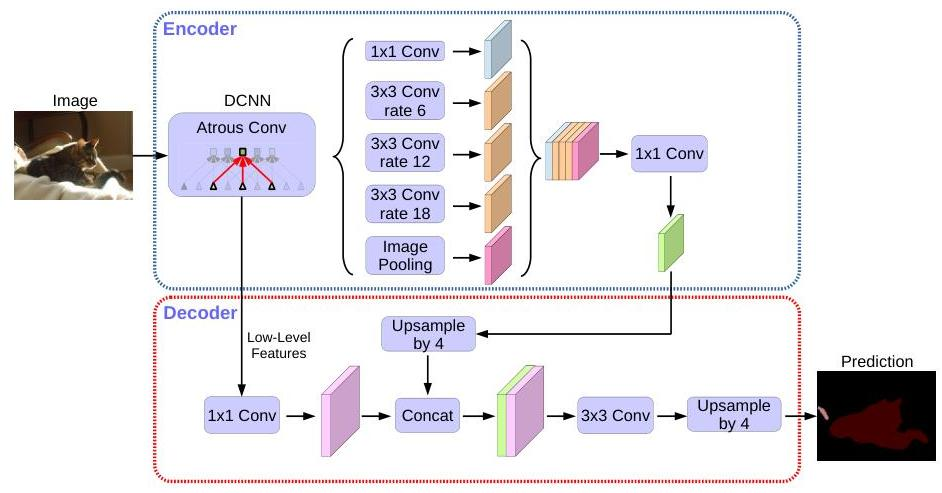

In [318]:
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

In [319]:
train_dataloader = DataLoader(train_dataset, num_workers=0, batch_size=4, shuffle=True)
val_dataloader = DataLoader(test_dataset, num_workers=0, batch_size=1, shuffle=False)

In [320]:
weights = DeepLabV3_ResNet101_Weights.DEFAULT
model = deeplabv3_resnet101(weights=weights)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
if model.aux_classifier is not None:
    model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(device)

В качестве лосса возьмем не Кросс-энтропию, а Dice лосс, так как в нем лучше соблюдается баланс между классами.

In [321]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.softmax(pred, dim=1)

        target_onehot = torch.nn.functional.one_hot(target, num_classes=pred.shape[1])
        target_onehot = target_onehot.permute(0, 3, 1, 2).float()

        intersection = torch.sum(pred * target_onehot, dim=(0, 2, 3))
        union = pred.sum(dim=(0, 2, 3)) + target_onehot.sum(dim=(0, 2, 3))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()
    
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def criterion(pred, target):
    return 0.7 * ce_loss(pred, target) + 0.3 * dice_loss(pred, target)


Оптимизатор менять не будем

In [322]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
num_epochs = 100 

Возьмем шедулер, для более плавной сходимости

In [323]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

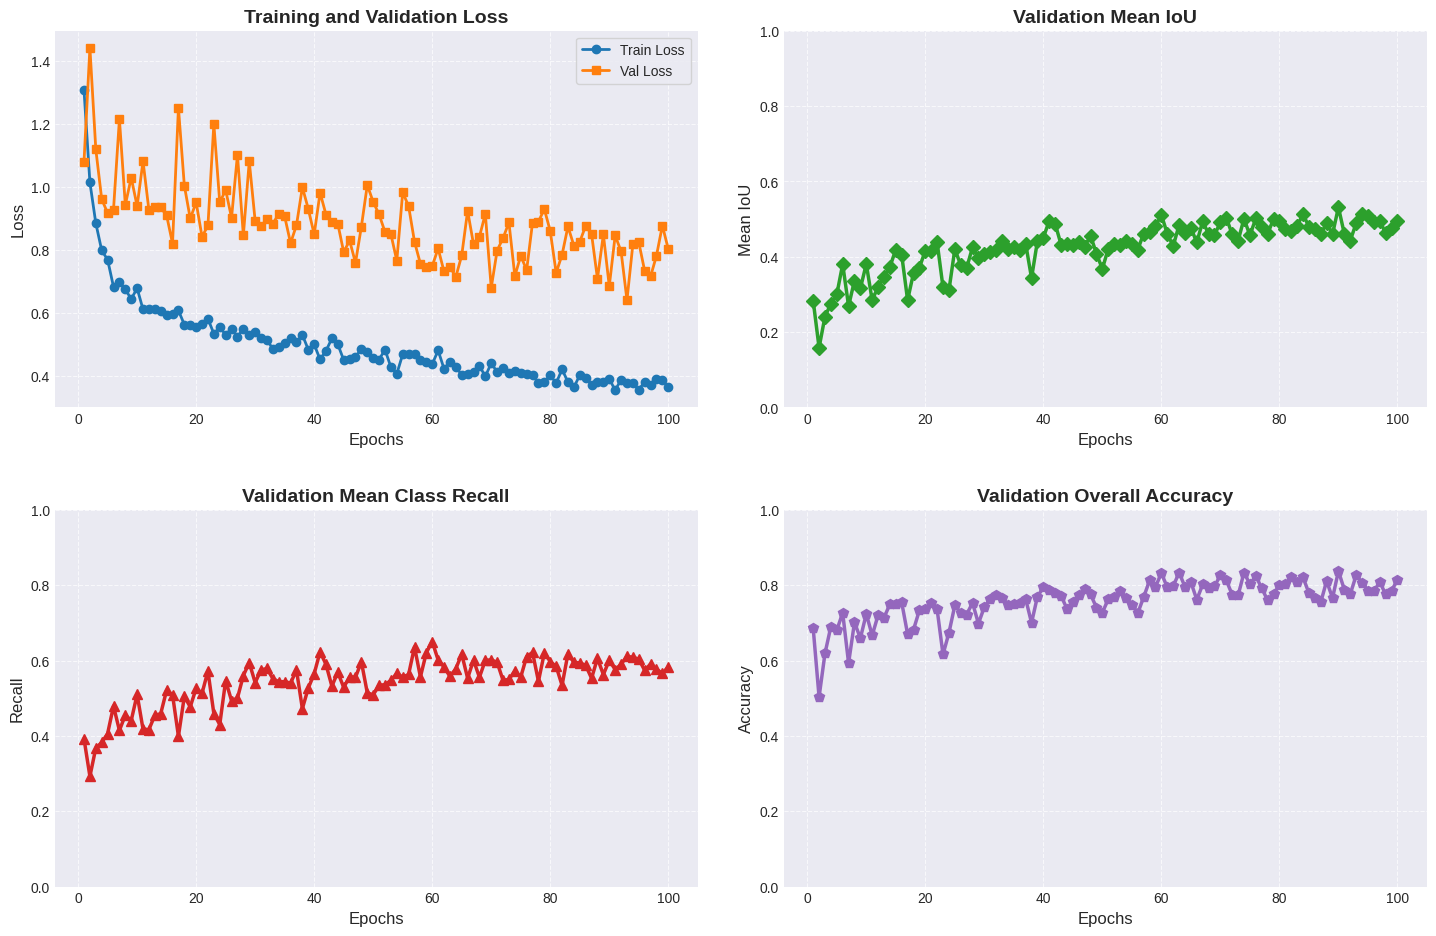

Epoch [100/100] - LR: 0.000000 - TrainLoss: 0.3660 - ValLoss: 0.8032 - mIoU: 0.4943 - Time: 9.6s

Лучшая модель сохранена: best_model_final_iou_0.5311.pth (mIoU = 0.5311)


In [324]:

plot_splits = 10
history, best_iou = train_segmentation_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    num_epochs=num_epochs,
    device=device,
    plot_splits=plot_splits,
    calc_val_data=calc_val_data,
    calc_val_loss=calc_val_loss,
    update_plots=update_plots,
    num_classes=NUM_CLASSES,
    scheduler=scheduler,
)

Загрузим лучшую модель

In [327]:
best_model = deeplabv3_resnet101(weights=None, aux_loss=True)
best_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
if best_model.aux_classifier is not None:
    best_model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

state_dict = torch.load(
    "/home/udeneev-av/DS_tasks/IAD/DL/best_model_final_iou_0.5311.pth",
    map_location="cpu",
)

best_model.load_state_dict(state_dict, strict=False)
best_model.to(device)
best_model.eval();

Посмотрим как она справляется с сегментацией.

/home/udeneev-av/tmp/ipykernel_4076705/3314046167.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


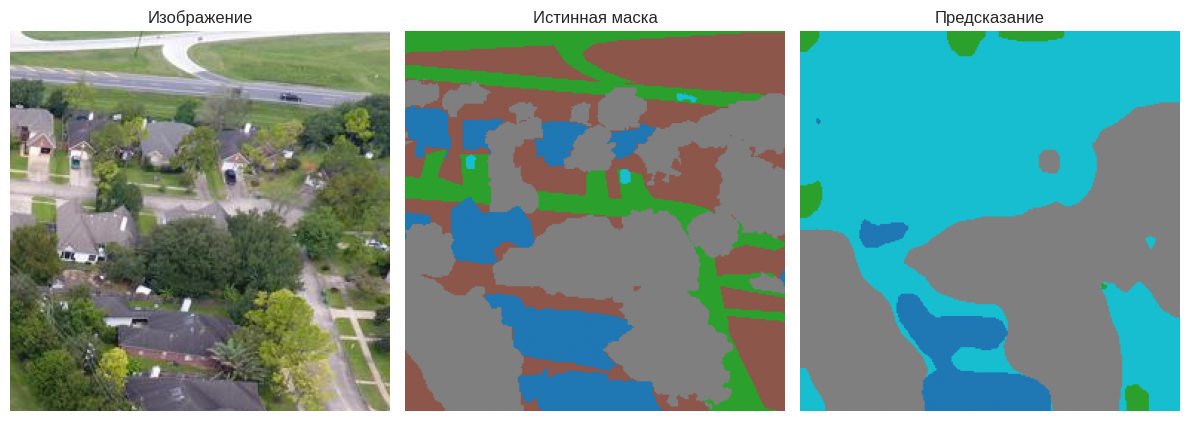

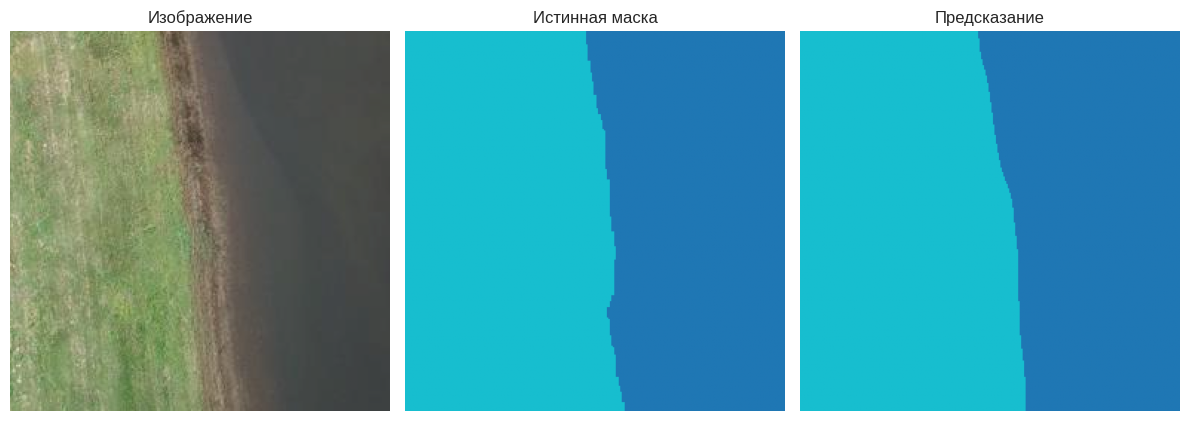

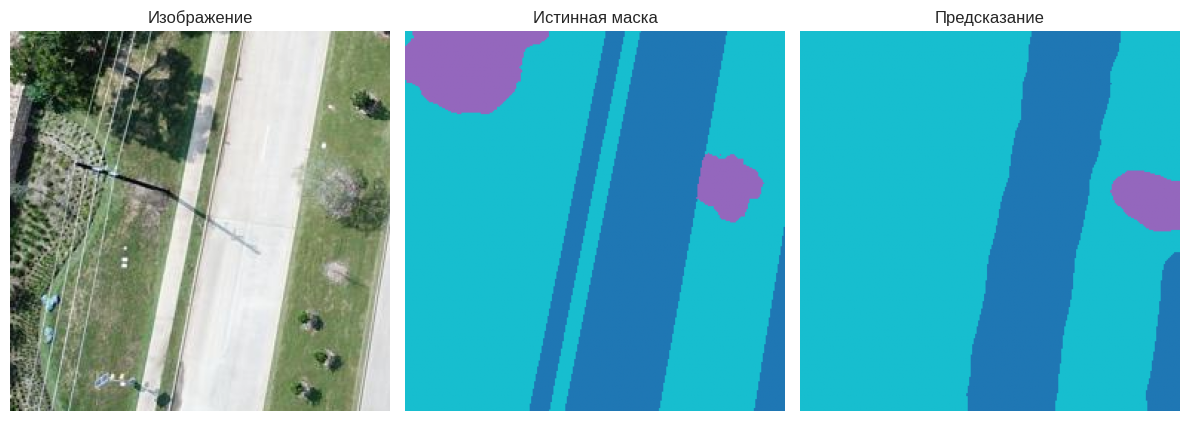

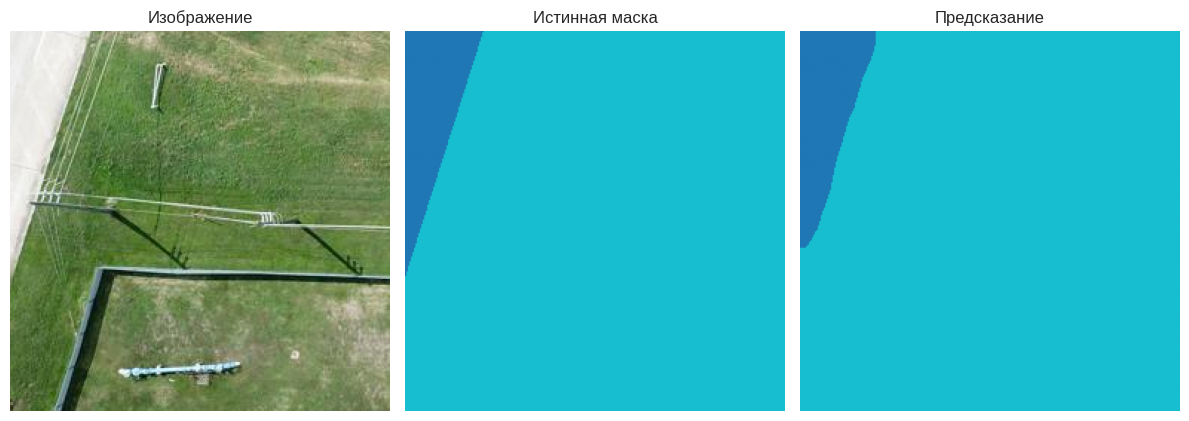

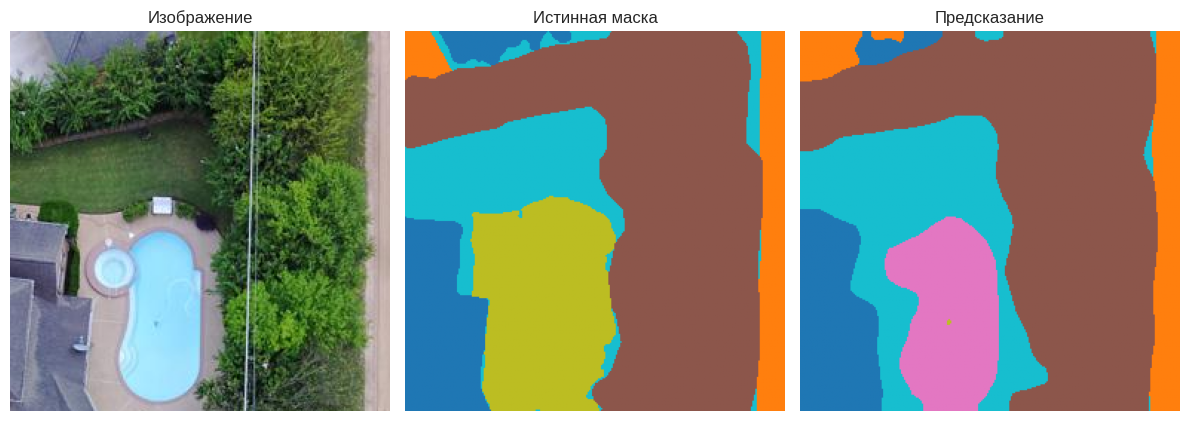

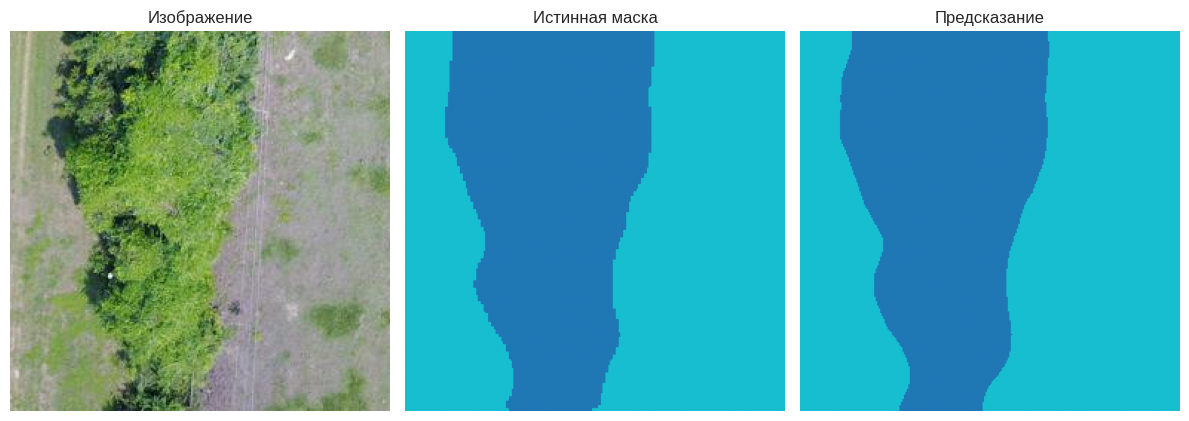

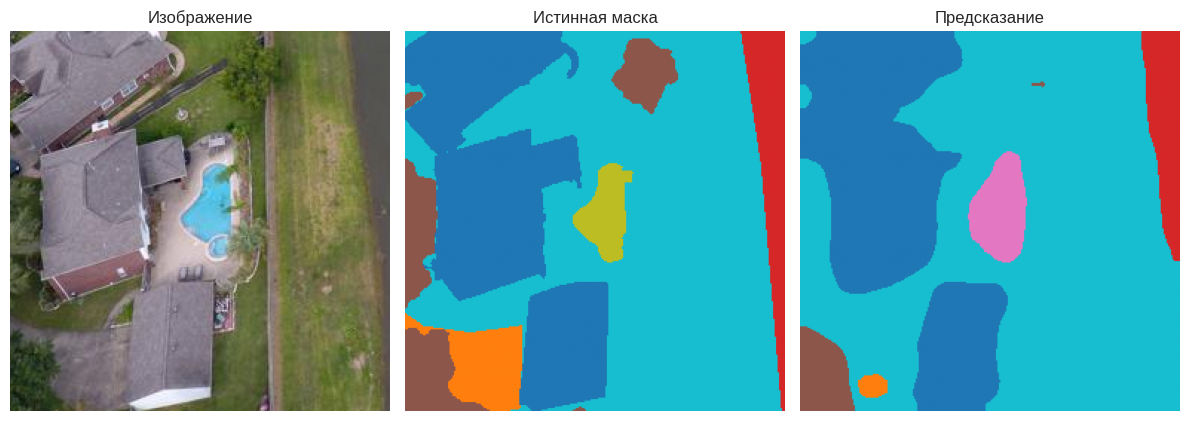

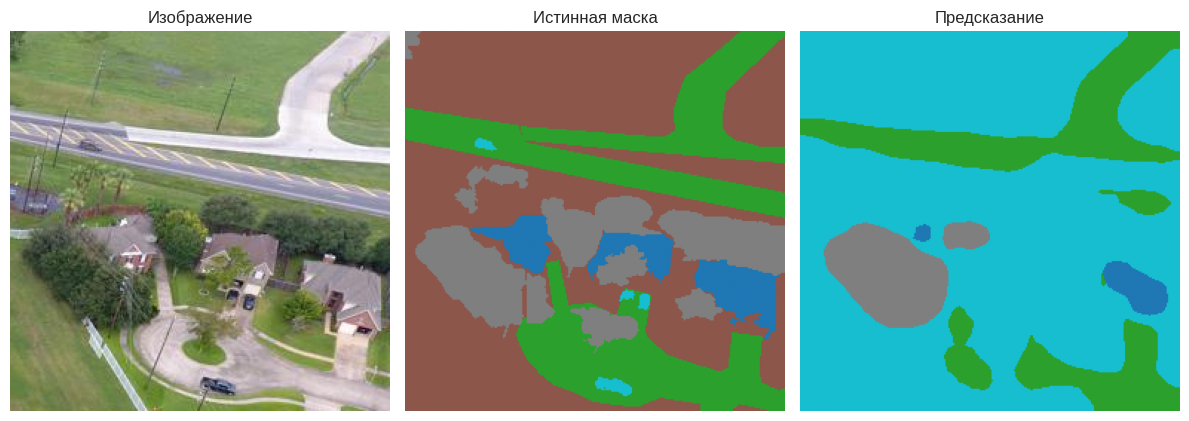

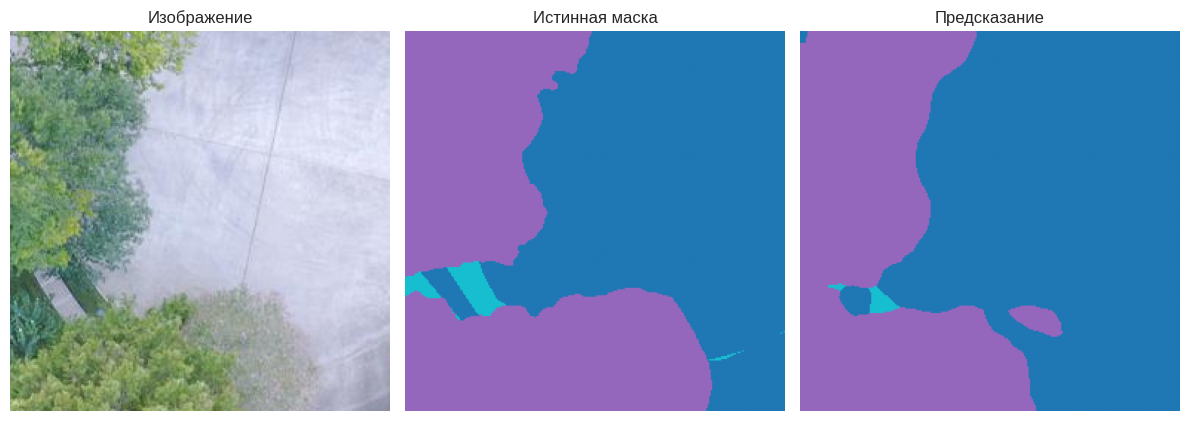

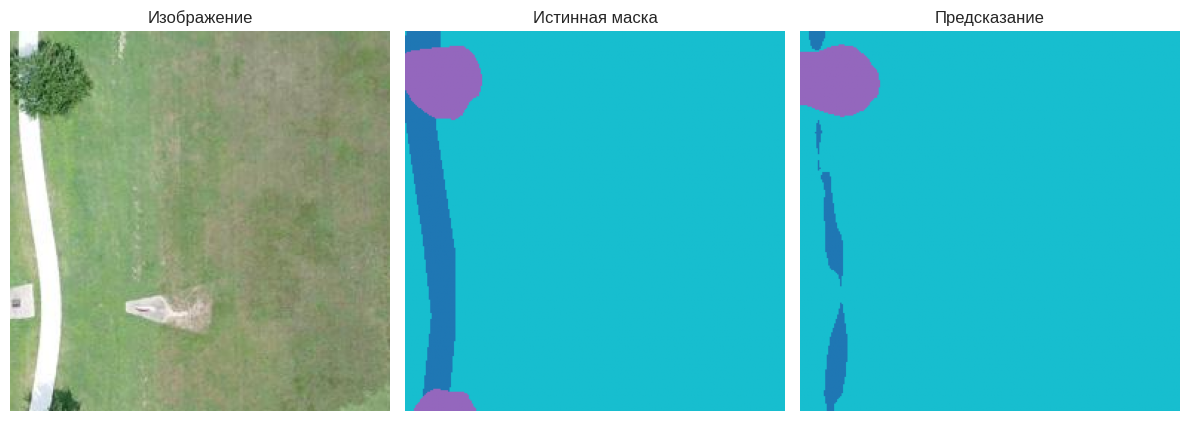

In [328]:
for i in range(10):
    plot_results(best_model, i)

**Выводы:**

Мы поработали с сегментацией объектов и написали свой UNET, который неплохо себя показал по основным метрикам.

В качестве улучшения я взял DeepLab v3, где при помощи Atrous сверток увеличивается поле зрения каждого пикселя. Благодаря atrous‑свёрткам с разными dilation, а также глобальному пулингу, модель получает более качественный глобальный и локальный контекст.

Известным минусом это модели является то, что она теряет мелкие детали, что отлично видно на иллюстрации.